## Project 17: Link prediction 2

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import powerlaw

Käytetty dataset: the Wikipedia vote network dataset. Saatavilla: https://snap.stanford.edu/data/wiki-Vote.html
Luodaan suunnattu graafi datasetistä.

In [2]:
G = nx.read_edgelist(
    "Wiki-Vote.txt",
    comments="#",
    nodetype=int,
    create_using=nx.DiGraph()
)

print(nx.number_of_nodes(G))
print(nx.number_of_edges(G))

7115
103689


Tehdään 100:n noden sample graafista ja visualisoidaan se.
TODO: paranna layoutia

<Figure size 640x480 with 0 Axes>

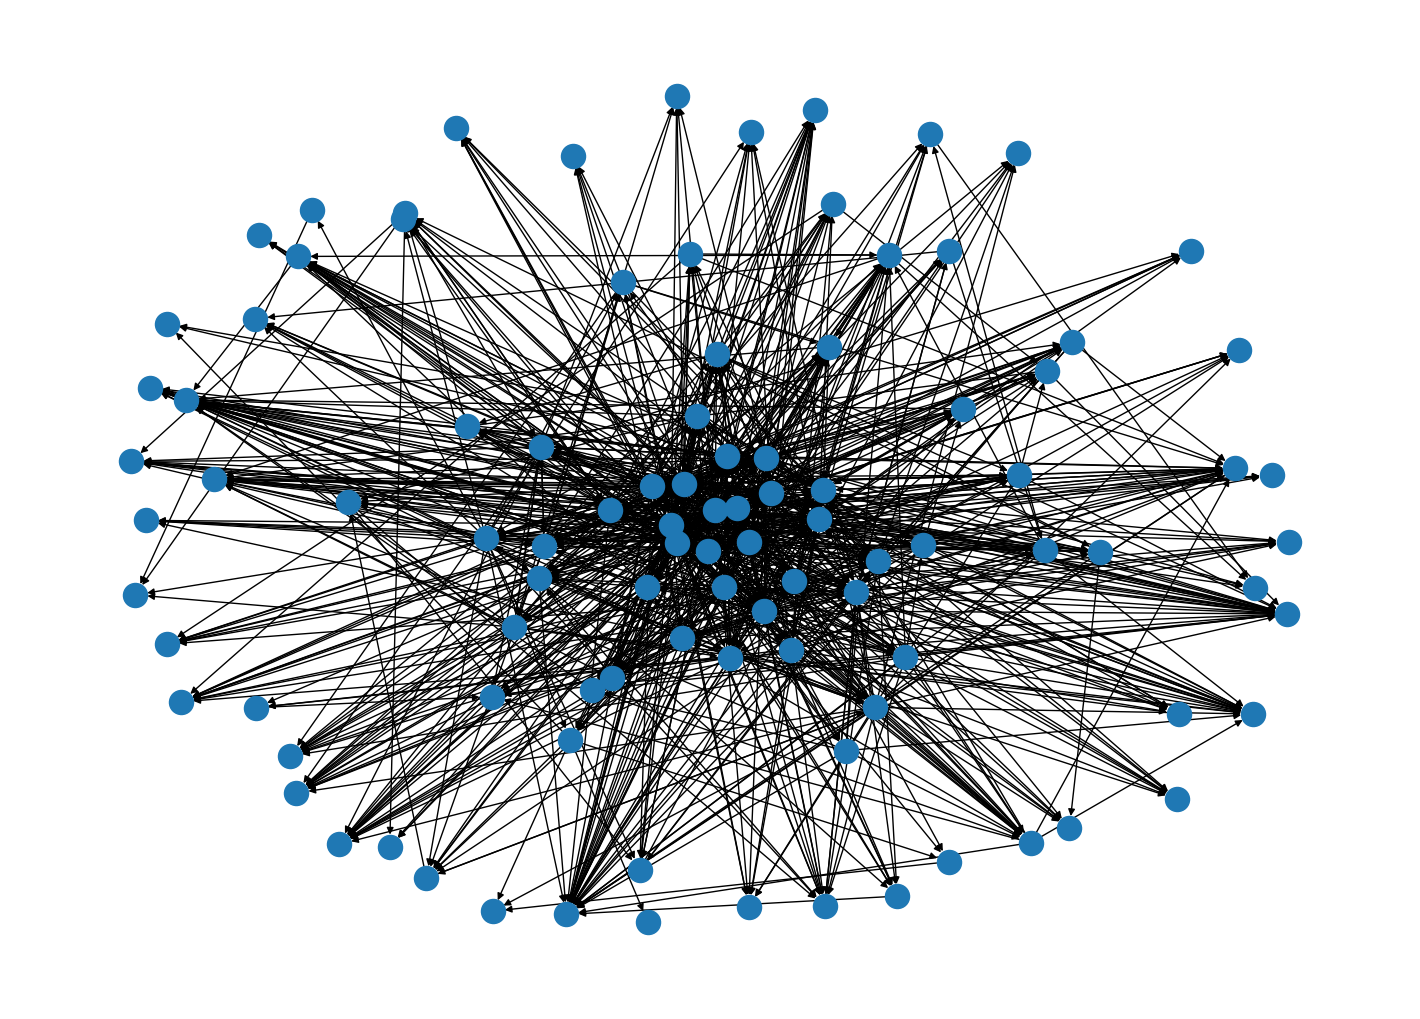

In [17]:
sample = G.subgraph(list(G.nodes())[:100])

plt.clf()
pos = nx.spring_layout(sample, seed=42, k=1)
plt.figure(figsize=(14, 10))
nx.draw(sample, pos, with_labels=False)
plt.show()


Tehdään adjancency matrix ja tallenetaan excel-tiedostoon
(tehty pelkästä samplesta, koska koko adjacency matrix olisi liian suuri)

In [4]:
adjacency_matrix = nx.adjacency_matrix(sample)

pandas_dataframe = pd.DataFrame(adjacency_matrix.toarray())
pandas_dataframe.to_excel("adjacency_matrix.xlsx")

Task2: TODO tarkista mitä tässä pitäisi tehdä

In [ ]:
#TODO

In-degree ja out-degree jakaumat

(array([5.90e+03, 4.64e+02, 2.55e+02, 1.25e+02, 9.90e+01, 6.60e+01,
        4.60e+01, 2.50e+01, 3.10e+01, 1.40e+01, 1.50e+01, 1.20e+01,
        1.30e+01, 9.00e+00, 3.00e+00, 8.00e+00, 4.00e+00, 8.00e+00,
        2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00,
        0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00]),
 array([  0.  ,  17.86,  35.72,  53.58,  71.44,  89.3 , 107.16, 125.02,
        142.88, 160.74, 178.6 , 196.46, 214.32, 232.18, 250.04, 267.9 ,
        285.76, 303.62, 321.48, 339.34, 357.2 , 375.06, 392.92, 410.78,
        428.64, 446.5 , 464.36, 482.22, 500.08, 517.94, 535.8 , 553.66,
        571.52, 589.38, 607.24, 625.1 , 642.96, 660.82, 678.68, 696.54,
        714.4 , 732.26, 750.12, 767.98, 785.84, 803.7 , 821.56, 83

<Figure size 640x480 with 0 Axes>

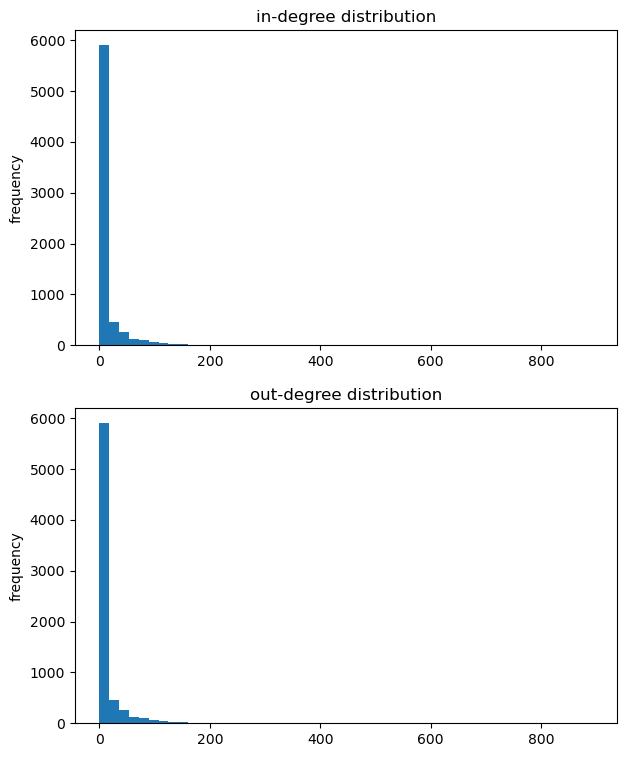

In [5]:
in_degrees = [d for n,d in G.in_degree()]
out_degrees = [d for n,d in G.out_degree()]

plt.clf()

plt.figure(figsize=(7, 9))

plt.subplot(2,1,1)
plt.title("in-degree distribution")
plt.ylabel("frequency")
plt.hist(out_degrees, bins=50)

plt.subplot(2,1,2)
plt.title("out-degree distribution")
plt.ylabel("frequency")
plt.hist(out_degrees, bins=50)

Power-law distribution

<Figure size 640x480 with 0 Axes>

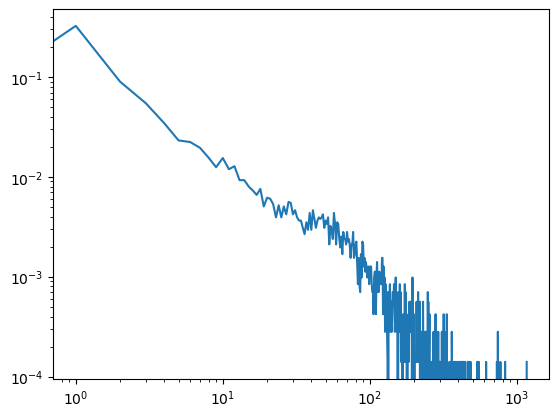

In [6]:

# compute the fraction of nodes (p_k) having degree k

histogram = nx.degree_histogram(G)

number_of_nodes = nx.number_of_nodes(G)

p_k = np.array(histogram) / number_of_nodes

# plot a log-log graph, where
#   x-axis: ln (k)
#   y-axis: ln (p_k)

k = np.arange(len(histogram))

plt.clf()
plt.figure()
plt.loglog(k, p_k)
plt.show()


Goodness of fit
Source: https://github.com/powerlaw-devs/powerlaw/tree/master

Calculating best minimal value for power law fit
/home/ella/miniconda3/envs/perusymparisto/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /


alpha =  4.14869966168172
xmin =   248.0
R = -0.09253396147097259
p = 0.783987231790295


/home/ella/miniconda3/envs/perusymparisto/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /


<Figure size 640x480 with 0 Axes>

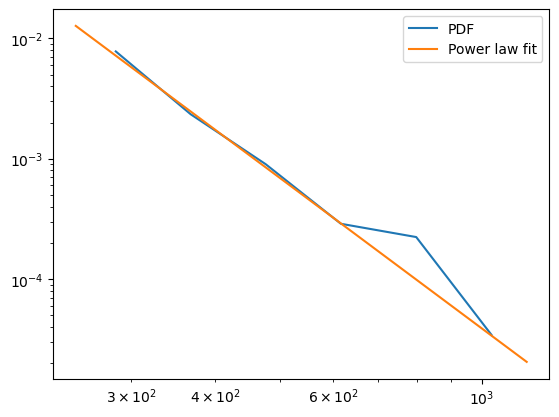

In [7]:
degrees = [d for n, d in G.degree()]

fit = powerlaw.Fit(degrees)

print("alpha = ", fit.power_law.alpha)
print("xmin =  ", fit.power_law.xmin)

R, p = fit.distribution_compare('power_law', 'lognormal')

print("R =", R)
print("p =", p)

plt.clf()

fig, ax = plt.subplots()

fit.plot_pdf(ax=ax, label='PDF')
fit.power_law.plot_pdf(ax=ax, label='Power law fit')

plt.legend()
plt.show()


--> noudattaa powerlaw 90% luottamusvälillä, kun degree > 248
TODO tämän selittäminen tarkemmin

Lasketaan reciprocity koko graafille

In [8]:
reciprocity = nx.overall_reciprocity(G)
print("reciprocity =", reciprocity)

reciprocity = 0.0564572905515532


n. 0.05% on kaksisuuntaisia -> suurin osa linkeistä on yksipuolisia

Top 10 betweennes centralityn mukaan ja top 10 closeness centralityn mukaan

In [10]:
betweenness_centrality = nx.betweenness_centrality(G)
betweenness_centrality_sorted = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
top_10_betweenness = [node for node, value in betweenness_centrality_sorted[:10]]

degree_centrality = nx.degree_centrality(G)
degree_centrality_sorted = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
top_10_centrality = [node for node, value in degree_centrality_sorted[:10]]

print(top_10_betweenness)
print(top_10_centrality)

[2565, 1549, 15, 72, 737, 1166, 5079, 2328, 2237, 28]
[2565, 1549, 766, 11, 1166, 457, 2688, 1374, 1151, 5524]


Huomataan, että top 2 on molemmissa samat: nodet 2565 ja 1549

In [14]:
ego_top1 = nx.ego_graph(G, 2565)
ego_top2 = nx.ego_graph(G, 1549)

<Figure size 640x480 with 0 Axes>

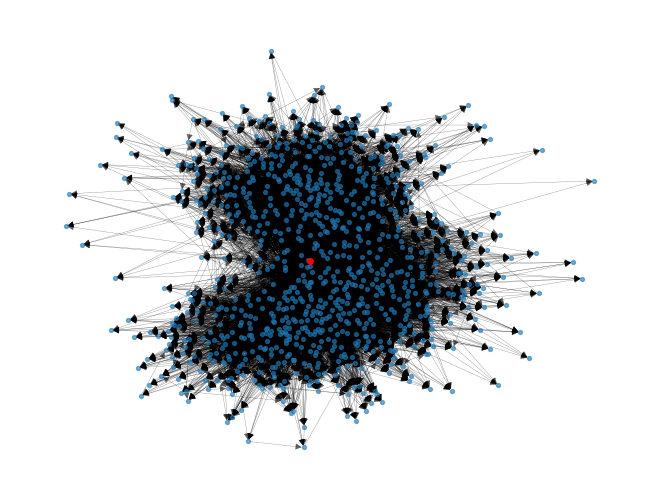

In [20]:
plt.clf()

pos = nx.spring_layout(ego_top1, seed=42, k=2)

plt.figure()

nx.draw(ego_top1, pos, node_size=8, width=0.2, alpha=0.6)
nx.draw_networkx_nodes(ego_top1, pos, nodelist=[2565], node_color='red', node_size=15)
plt.show()


<Figure size 640x480 with 0 Axes>

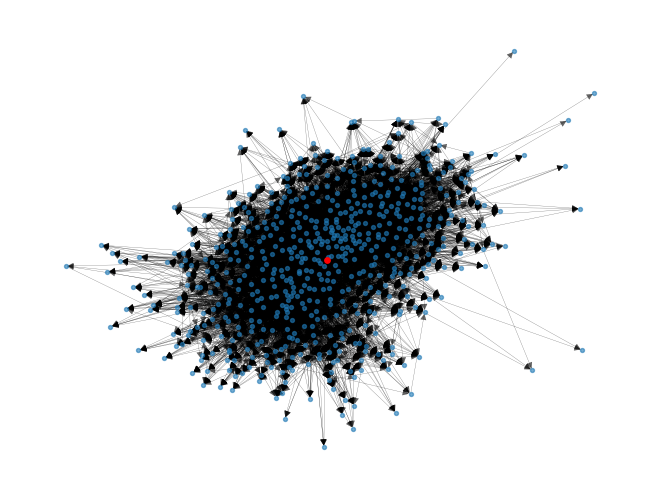

In [21]:
plt.clf()

pos = nx.spring_layout(ego_top2, seed=42, k=2)

plt.figure()

nx.draw(ego_top2, pos, node_size=8, width=0.2, alpha=0.6)
nx.draw_networkx_nodes(ego_top1, pos, nodelist=[1549], node_color='red', node_size=15)
plt.show()